In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [2]:
load_dotenv()


True

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:

subgraph_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7
)

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:

subgraph_builder = StateGraph(SubState)
subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

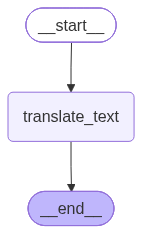

In [13]:
subgraph

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [8]:

parent_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7
)

In [9]:

def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:

def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

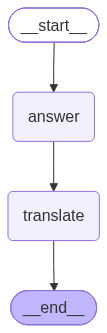

In [12]:
graph = parent_builder.compile()

graph

In [14]:
graph.invoke({'question': 'What is quantum physics'})

e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'question': 'What is quantum physics',
 'answer_eng': [{'type': 'text',
   'text': '**Quantum physics** (also known as quantum mechanics) is the branch of science that studies the fundamental building blocks of the universe at the smallest scales—specifically, atoms and subatomic particles (like electrons, protons, and photons).\n\nWhile classical physics (like Newtonian mechanics) explains how big things work—like falling apples, moving cars, and orbiting planets—it breaks down at the atomic and subatomic level. Quantum physics explains how nature works in that microscopic realm, where the rules are very different and often counterintuitive.\n\nHere are the key principles that make quantum physics unique:\n\n1. **Quantization:** Unlike everyday energy or matter, which can flow in a continuous stream, certain properties at the quantum level come in discrete, indivisible packets called **quanta**. For example, light is emitted or absorbed in tiny packets called photons.\n2. **Wave-Part